#**TP 3**

#### **1. Fourier transform (1D)**

#### **1.1) Construction du signal**

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [39]:
SF = 50
SP = 1 / SF
t = np.arange(0,1,SP)
s = 1+np.cos(2*np.pi*5*t) + 0.3*np.cos(2*np.pi*9*t)

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_1959/70256255.py:2: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(t, s, label='$s(t) = 1 + \cos(10\pi t) + 0.3\cos(18\pi t)$')


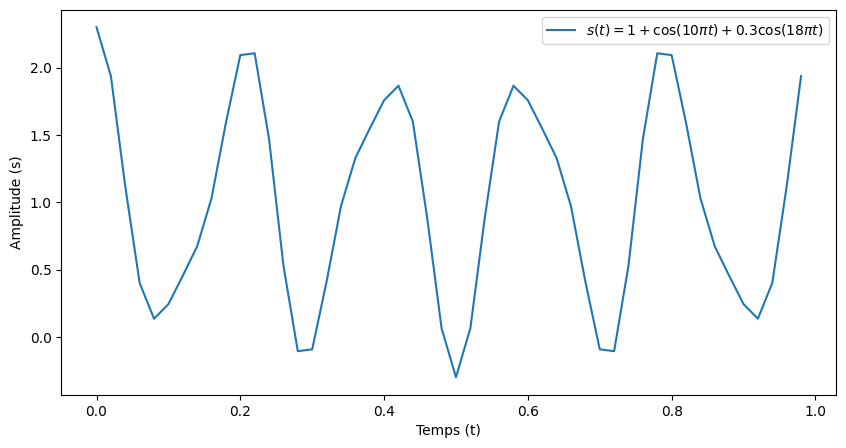

In [40]:
plt.figure(figsize=(10, 5))
plt.plot(t, s, label='$s(t) = 1 + \cos(10\pi t) + 0.3\cos(18\pi t)$')
plt.xlabel('Temps (t)')
plt.ylabel('Amplitude (s)')
plt.legend()
plt.show()

#### **1.2) Transformée de Fourier 1D**

In [41]:

def fourier1D(s, fe):
    # s est le signal d'entrée et fe est la fréquence d'échantillonnage

    N = len(s)
    n = len(s) / 2

    a = np.abs(np.fft.fftshift(np.fft.fft(s))) / N

    x = fe * (np.arange(-np.floor(n), np.ceil(n))) / N

    plt.bar(x, a)
    plt.xlabel('Fréquence (Hz)')
    plt.ylabel('Amplitude')
    plt.show()


def wave(n, m, fy, fx):
    e1 = np.exp(-1j * 2 * np.pi * fx * np.arange(m))
    e2 = np.exp(1j * 2 * np.pi * fy * np.arange(n))
    img = np.outer(e2, e1).real
    return img


def fourier2d_single_frenquency(img):

    f = np.fft.fft2(img - np.mean(img))
    fshift = np.fft.fftshift(f)

    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)

    rows, cols = img.shape
    freq_x = np.fft.fftfreq(cols)
    freq_y = np.fft.fftfreq(rows)

    plt.imshow(
        magnitude_spectrum,
        cmap='gray',
        extent=(freq_x.min(), freq_x.max(), freq_y.min(), freq_y.max())
    )
    plt.xlabel('Frequency (cycles per pixel)')
    plt.ylabel('Frequency (cycles per pixel)')
    plt.show()


def fourier2d_vue3d_old(img, fe):

    M, N = img.shape

    cx = np.arange(N) - np.floor(N / 2)
    cy = np.arange(M) - np.floor(M / 2)

    max_fx = fe * N
    max_fy = fe * M

    X, Y = np.meshgrid(fe * cx / max_fx, fe * cy / max_fy)

    Z = np.abs(np.fft.fft2(img - np.mean(img)))
    Z = np.fft.fftshift(Z) / (N * M)

    fig = plt.figure(figsize=(12, 6))

    ax1 = fig.add_subplot(121)
    ax1.imshow(img, cmap='gray')
    ax1.set_title('Image originale')

    ax2 = fig.add_subplot(122, projection='3d')
    ax2.set_title('Module de la transformée de Fourier 2D')
    ax2.set_xlabel('Fx (Hz)')
    ax2.set_ylabel('Fy (Hz)')
    ax2.set_zlabel('Module')

    ax2.plot_surface(X, Y, Z, cmap='viridis')

    plt.show()


def fourier2d_many_frequencies(img):

    f = np.fft.fft2(img - np.mean(img))
    fshift = np.fft.fftshift(f)

    magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1e-8)

    rows, cols = img.shape
    freq_x = np.fft.fftfreq(cols)
    freq_y = np.fft.fftfreq(rows)

    plt.subplot(2, 2, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')

    plt.subplot(2, 2, 2)
    plt.imshow(
        magnitude_spectrum,
        cmap='gray',
        extent=(freq_x.min(), freq_x.max(), freq_y.min(), freq_y.max())
    )
    plt.title('Magnitude Spectrum')
    plt.xlabel('Frequency (cycles per pixel)')
    plt.ylabel('Frequency (cycles per pixel)')

    # --------- FIXED 3D PART ----------
    X, Y = np.meshgrid(freq_x, freq_y)
    Z = 20 * np.log(np.abs(fshift) + 1e-8)

    fig = plt.figure(figsize=(6, 5))
    ax = plt.figure().add_subplot(111, projection='3d')

    ax.plot_surface(X, Y, Z, cmap='gray')
    ax.set_xlabel('Frequency X (cycles per pixel)')
    ax.set_ylabel('Frequency Y (cycles per pixel)')
    ax.set_zlabel('Magnitude')

    plt.title('3D Fourier Spectrum')

    plt.show()


def fourier2d_all(img):

    f_x = np.fft.fft(img, axis=0)
    f_y = np.fft.fft(img, axis=1)

    max_freq_x = np.argmax(np.abs(f_x))
    max_freq_y = np.argmax(np.abs(f_y))

    if (max_freq_x == 0 and max_freq_y != 0) or (max_freq_x != 0 and max_freq_y == 0):
        fourier2d_single_frenquency(img)
    else:
        fourier2d_many_frequencies(img)

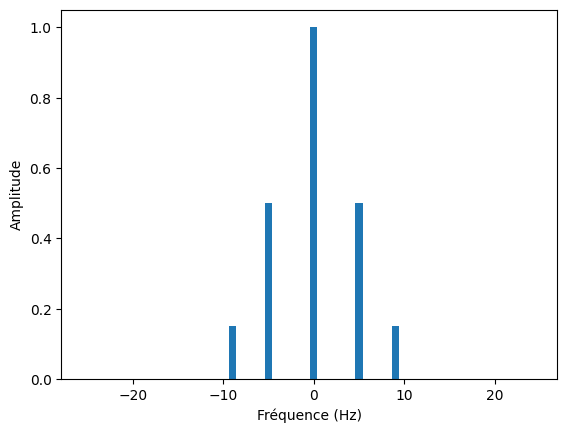

In [42]:
# Appliquer la 1D Fourier transform sur s
fourier1D(s,SF)

##**2. Transformée de Fourier 2D sur images sinusoïdales**

####**2.1) Image sinusoïdale verticale**

In [43]:
img = wave(128, 128, 0.1, 0) # pour une oscillation uniquement verticale de fréquence 0.1

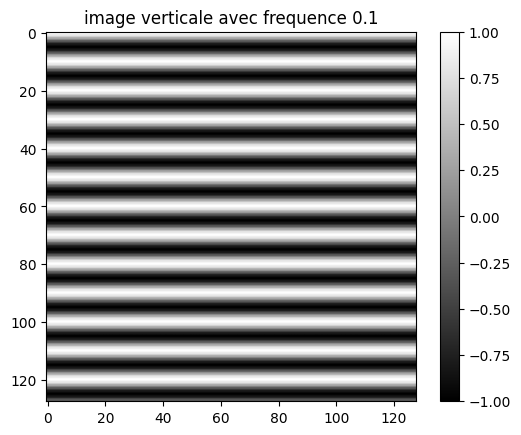

In [44]:
plt.imshow(img, cmap='gray')
plt.title("image verticale avec frequence 0.1")
plt.colorbar()
plt.show()

####**2.2 - Spectre de Fourier de l'image verticale**

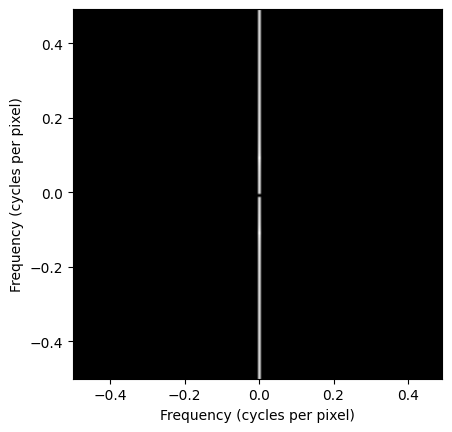

In [45]:
fourier2d_all(img)

#####**Interpretation:**
- Deux pics symétriques sur l'axe vertical et rien sur l'axe horizontal

####**2.3 - Oscillation horizontale**

In [46]:
img_horiz = wave(128, 128, 0, 0.1) # pour une oscillation uniquement verticale de fréquence 0.1

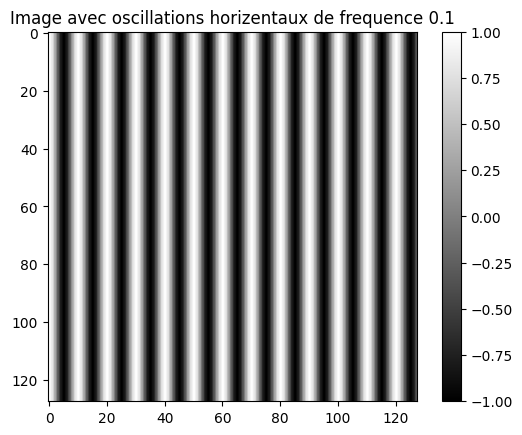

In [47]:
plt.imshow(img_horiz, cmap='gray')
plt.title("Image avec oscillations horizentaux de frequence 0.1")
plt.colorbar()
plt.show()

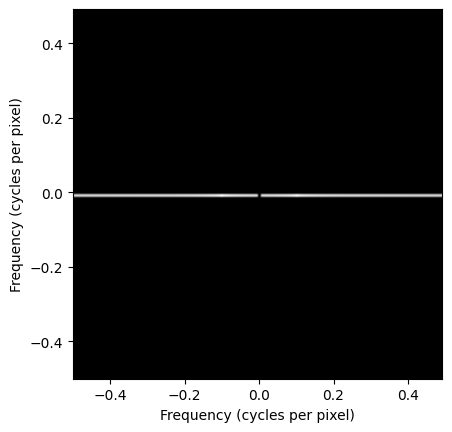

In [48]:
# Spectre
fourier2d_all(img_horiz)

####**2.4 - Oscillations sur les deux axes**

In [49]:
img_V_H = wave(128, 128, 0.1, 0.3)

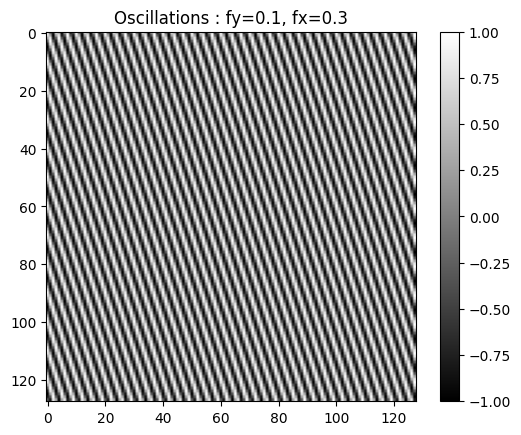

In [50]:
plt.imshow(img_V_H, cmap='gray')
plt.title("Oscillations : fy=0.1, fx=0.3")
plt.colorbar()
plt.show()

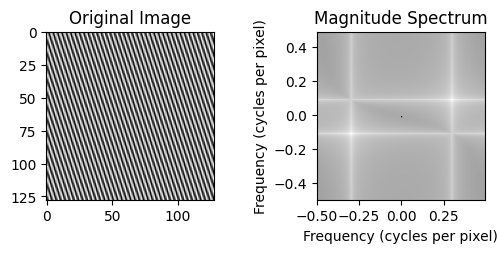

<Figure size 600x500 with 0 Axes>

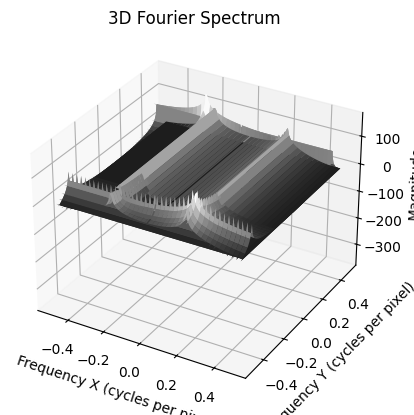

In [51]:
# Spectre
fourier2d_all(img_V_H)

##**3. Transformée de Fourier sur images synthétiques**

In [54]:
# Lister tous les images du dossier 'Synthetic_images'

import os
fichiers = os.listdir('/content/Synthetic_images')

extensions_images = ['.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff']
images = [f for f in fichiers if any(f.lower().endswith(ext) for ext in extensions_images)]

print(f"Images trouvées : {images}")

Images trouvées : ['oval3.bmp', 'oval6.bmp', 'oval0.bmp', 'eau.bmp', 'rupt0.bmp', 'oval5.bmp', 'oval2.bmp', 'sable.bmp']



=== Analyse de oval3.bmp ===


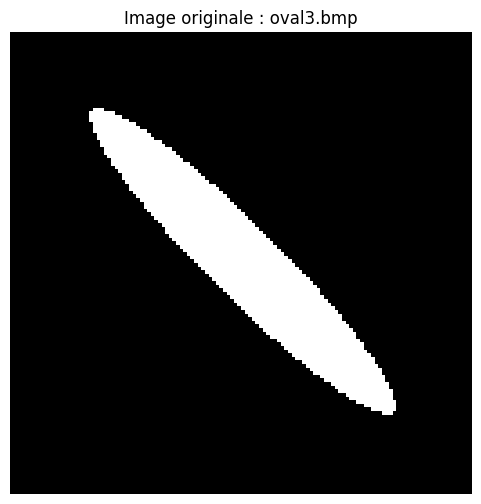

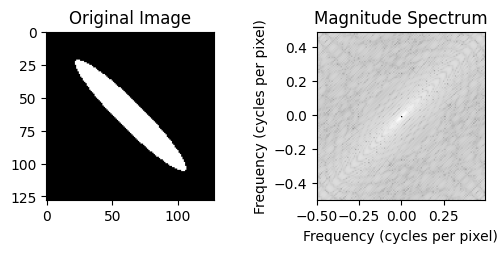

<Figure size 600x500 with 0 Axes>

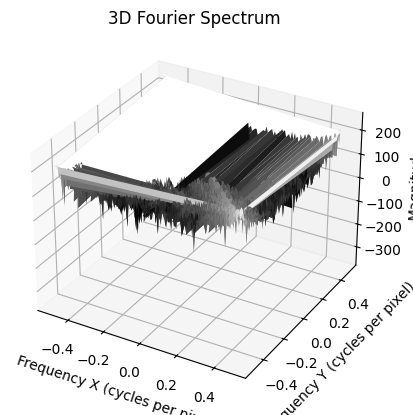


=== Analyse de oval6.bmp ===


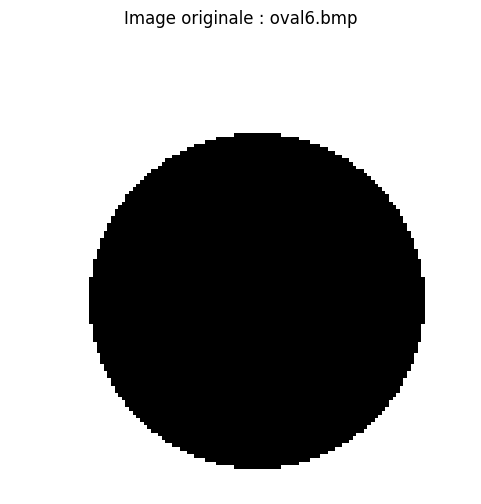

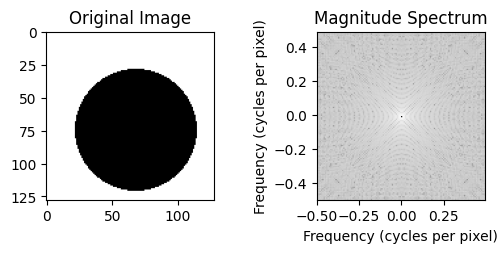

<Figure size 600x500 with 0 Axes>

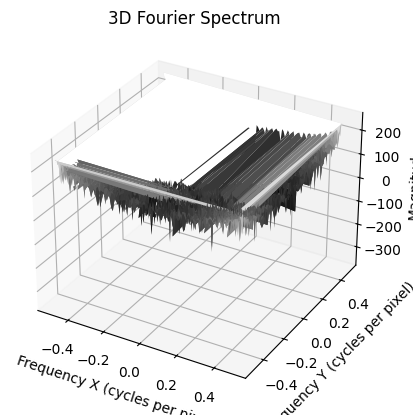


=== Analyse de oval0.bmp ===


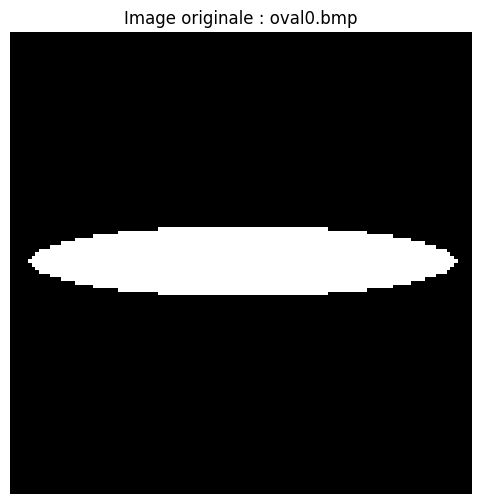

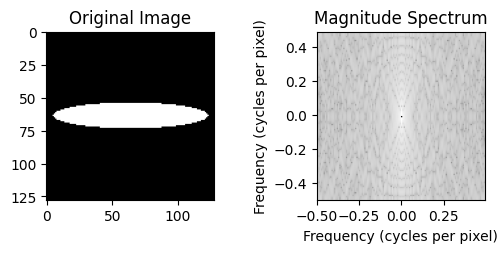

<Figure size 600x500 with 0 Axes>

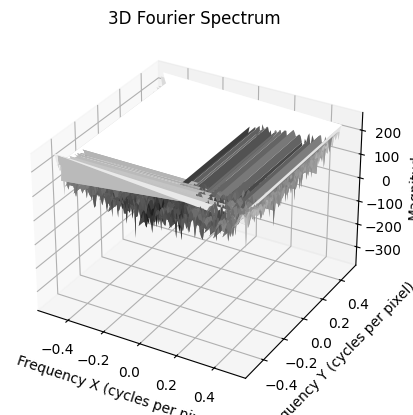


=== Analyse de eau.bmp ===


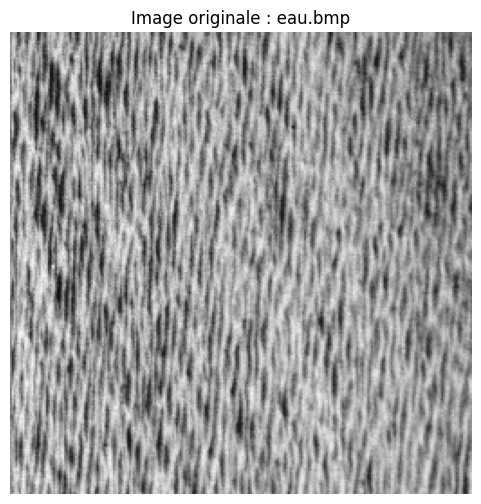

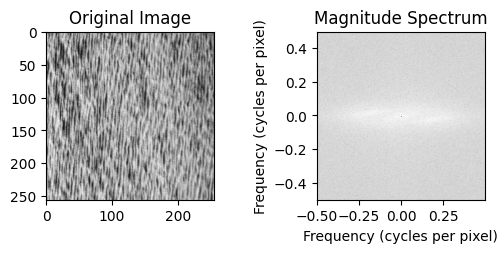

<Figure size 600x500 with 0 Axes>

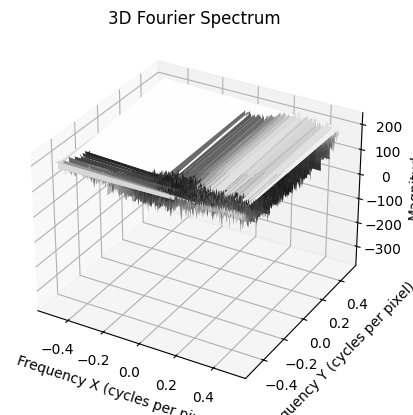


=== Analyse de rupt0.bmp ===


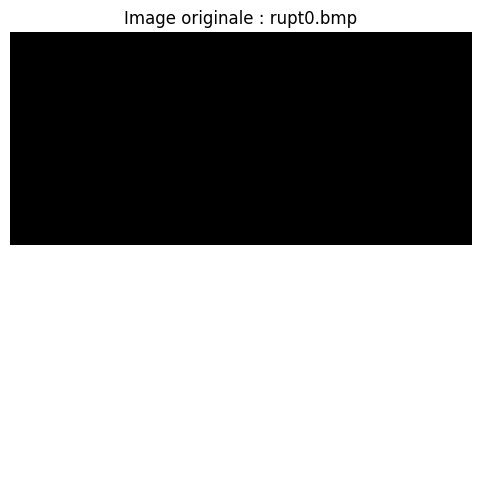

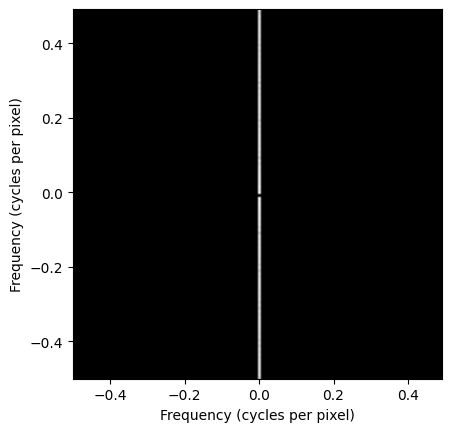


=== Analyse de oval5.bmp ===


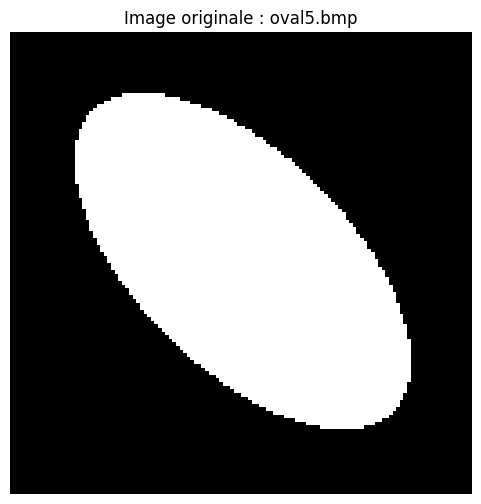

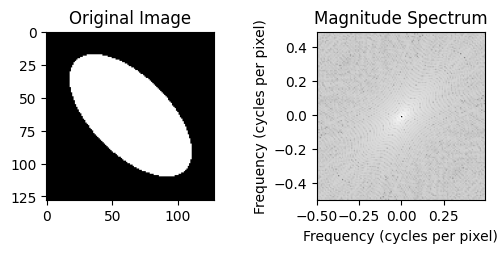

<Figure size 600x500 with 0 Axes>

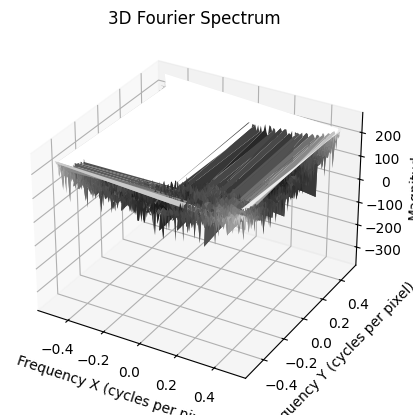


=== Analyse de oval2.bmp ===


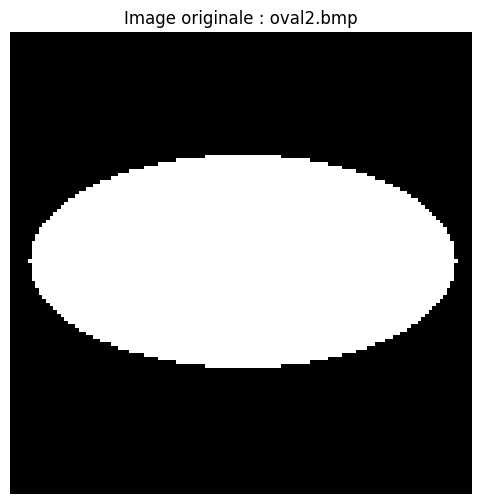

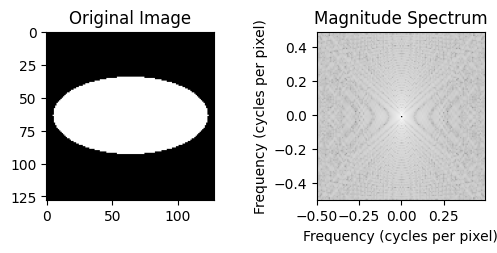

<Figure size 600x500 with 0 Axes>

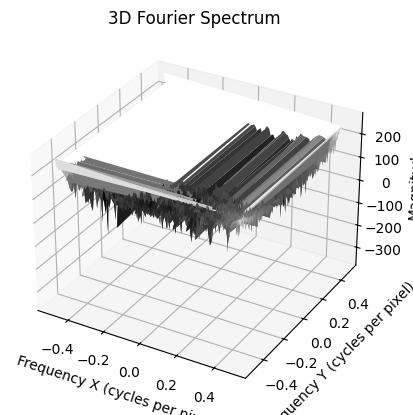


=== Analyse de sable.bmp ===


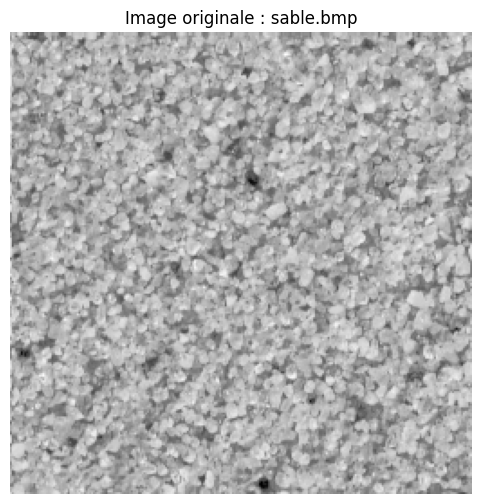

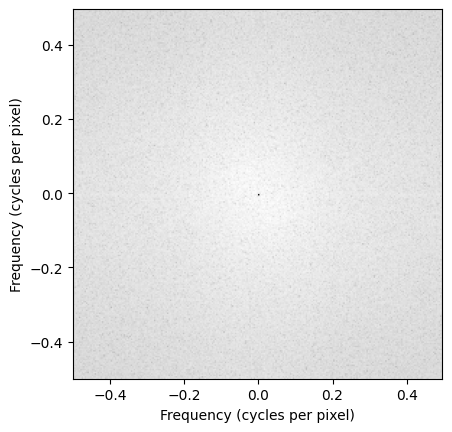

In [57]:
# Traiter chaque image
import matplotlib.image as mpimg

for nom_image in images:
    print(f"\n=== Analyse de {nom_image} ===")

    # Charger l'image
    chemin_complet = os.path.join('/content/Synthetic_images', nom_image)
    img = mpimg.imread(chemin_complet)

    # Convertir en niveaux de gris
    if len(img.shape) == 3:
        img = img.mean(axis=2)  # Moyenne des canaux RGB

    # Afficher l'image originale
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='gray')
    plt.title(f"Image originale : {nom_image}")
    plt.axis('off')
    plt.show()

    # Appliquer la transformée de Fourier avec la fonction du cours
    fourier2d_all(img)

##**4. Filtrage par transformée de Fourier 2D**

####**4.1) Filtrage passe-bas sur Lena**

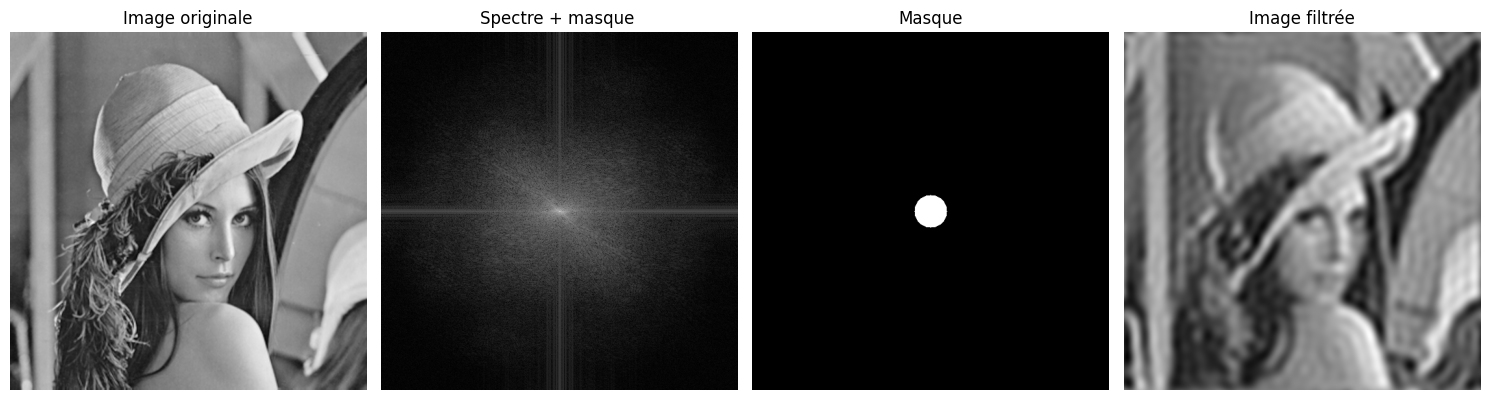

In [67]:
def filtrage_passe_bas(chemin_image, R):
    # 1. Charger l'image
    img = mpimg.imread(chemin_image)
    if len(img.shape) == 3:
        img = img.mean(axis=2)  # Conversion en niveaux de gris

    M, N = img.shape

    # 2. Calculer la FFT 2D et la centrer
    F = np.fft.fft2(img)
    F_shift = np.fft.fftshift(F)

    # 3. Créer le masque circulaire
    masque = np.zeros((M, N))
    centre_y, centre_x = M // 2, N // 2

    # Créer une grille de coordonnées
    Y, X = np.ogrid[:M, :N]
    distance = np.sqrt((X - centre_x)**2 + (Y - centre_y)**2)
    # Mettre à 1 les pixels dans le cercle de rayon R
    masque[distance <= R] = 1

    # 4. Appliquer le masque au spectre
    F_filtre = F_shift * masque

    # 5. FFT inverse
    F_inverse = np.fft.ifftshift(F_filtre)
    img_filtree = np.fft.ifft2(F_inverse)
    img_filtree = np.abs(img_filtree)  # Prendre le module (normalement réel)

    # 6. Visualisation
    plt.figure(figsize=(15, 5))

    # Image originale
    plt.subplot(1, 4, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Image originale')
    plt.axis('off')

    # Spectre avec masque superposé
    plt.subplot(1, 4, 2)
    magnitude_spectre = 20 * np.log(np.abs(F_shift) + 1)  # +1 pour éviter log(0)
    plt.imshow(magnitude_spectre, cmap='gray')
    plt.title(f'Spectre + masque ')
    plt.axis('off')

    # Masque seul
    plt.subplot(1, 4, 3)
    plt.imshow(masque, cmap='gray')
    plt.title('Masque')
    plt.axis('off')

    # Image filtrée
    plt.subplot(1, 4, 4)
    plt.imshow(img_filtree, cmap='gray')
    plt.title('Image filtrée')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return img_filtree

# Test avec notre image Lena
img_filtree = filtrage_passe_bas('/content/ressources2/lena.png', R=25)

####**4.2) Type de filtrage et amélioration**

- **Type** : Filtre passe-bas idéal

- **Amélioration** : Utiliser un filtre gaussien pour éviter les artefacts de Gibbs

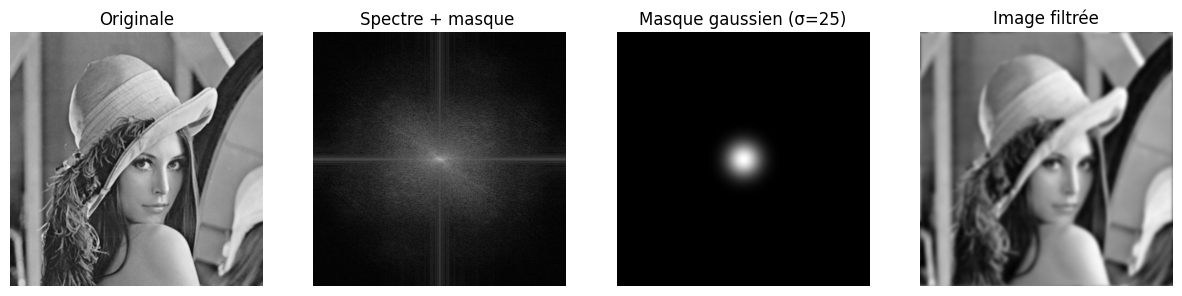

In [75]:
def filtrage_passe_bas_gaussien(chemin_image, sigma):

    img = mpimg.imread(chemin_image)
    if len(img.shape) == 3:
        img = img.mean(axis=2)

    M, N = img.shape

    # FFT
    F = np.fft.fft2(img)
    F_shift = np.fft.fftshift(F)

    # masque gaussien
    Y, X = np.ogrid[:M, :N]
    centre_y, centre_x = M // 2, N // 2
    distance = np.sqrt((X - centre_x)**2 + (Y - centre_y)**2)
    masque = np.exp(-(distance**2) / (2 * sigma**2))

    # Appliquer le filtre
    F_filtre = F_shift * masque

    # FFT inverse
    F_inverse = np.fft.ifftshift(F_filtre)
    img_filtree = np.abs(np.fft.ifft2(F_inverse))

    # Visualisation
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 4, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Originale')
    plt.axis('off')

    # Spectre avec masque
    plt.subplot(1, 4, 2)
    magnitude_spectre = 20 * np.log(np.abs(F_shift) + 1)  # +1 pour éviter log(0)
    plt.imshow(magnitude_spectre, cmap='gray')
    plt.title(f'Spectre + masque ')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(masque, cmap='gray')
    plt.title(f'Masque gaussien (σ={sigma})')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(img_filtree, cmap='gray')
    plt.title('Image filtrée')
    plt.axis('off')

    plt.show()

    return img_filtree

# Test
img_filtree_douce = filtrage_passe_bas_gaussien('/content/ressources2/lena.png', sigma=25)

####**4.3) Filtrage inverse (passe-haut)**

- On garde les hautes fréquences (les details, contours) et on supprime les basses fréquences.



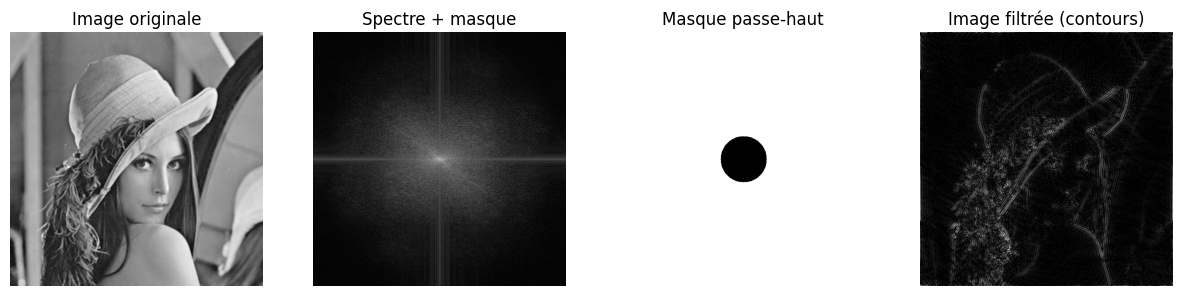

In [78]:
def filtrage_passe_haut(chemin_image, R):

    img = mpimg.imread(chemin_image)
    if len(img.shape) == 3:
        img = img.mean(axis=2)

    M, N = img.shape

    # FFT
    F = np.fft.fft2(img)
    F_shift = np.fft.fftshift(F)

    # Créer le masque inverse (1 - masque passe-bas)
    Y, X = np.ogrid[:M, :N]
    centre_y, centre_x = M // 2, N // 2
    distance = np.sqrt((X - centre_x)**2 + (Y - centre_y)**2)

    masque_passe_bas = np.zeros((M, N))
    masque_passe_bas[distance <= R] = 1
    masque_passe_haut = 1 - masque_passe_bas

    # Appliquer le filtre
    F_filtre = F_shift * masque_passe_haut

    # FFT inverse
    F_inverse = np.fft.ifftshift(F_filtre)
    img_filtree = np.abs(np.fft.ifft2(F_inverse))

    # Visualisation
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Image originale')
    plt.axis('off')

    plt.subplot(1, 4, 2)
    magnitude = 20 * np.log(np.abs(F_shift) + 1)
    plt.imshow(magnitude, cmap='gray')
    plt.title('Spectre + masque')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(masque_passe_haut, cmap='gray')
    plt.title('Masque passe-haut')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(img_filtree, cmap='gray')
    plt.title('Image filtrée (contours)')
    plt.axis('off')

    plt.show()

    return img_filtree

# Test
img_contours = filtrage_passe_haut('/content/ressources2/lena.png', R=50)

#-**Merci!**-